### **Exercice d'application**

Afin d'appliquer ce que vous venez d'apprendre, je vous propose de mener l'enquête avec Agatha Christie, en incarnant le Hercule Poirot du NLP pour démasquer le coupable...

<img src="https://www.citoyens-justice.fr/k-stock/data/visuel-site/investigation-judiciaire.png" alt="maj_to_min" width="400">

Pour cela, vous devrez commencer par télécharger [ce fichier](https://github.com/amandinejvl/ObTIC/blob/main/atelier_preprocessing/data/agatha_christie.txt) puis l'importer dans Google Drive.

Il s'agit du roman d'Agatha Christie _Ils étaient dix_ (1939).

#

<img src="https://static.wikia.nocookie.net/lunivers-dagatha-christie/images/1/13/Ils_%C3%A9taient_dix_%C3%A9dition_fran%C3%A7aise_.jpg/revision/latest?cb=20250314175546&path-prefix=fr" alt="maj_to_min" width="200">

**Mise en situation**

Vera Claythorne, institutrice, est engagée comme secrétaire auprès d'une certaine madame Owen, qui vit avec son époux sur l'île du Nègre, sur la côte du Devon, en Angleterre. En arrivant sur place, la jeune femme découvre qu'elle doit composer avec la présence de nombreux invités qui ne se connaissent pas. Les propriétaires, eux, sont mystérieusement absents. Au cours de la soirée, chaque convive est accusé d'un ou plusieurs meurtres.

Dans les quelques jours qui suivent, tous les invités, qui ne se connaissaient pas entre eux, meurent brutalement l'un après l'autre, à chaque fois d'une façon qui rappelle les couplets d'une comptine intitulée _Dix Petits Nègres_.

Afin d'élucider cette série de crimes, la police a décidé de faire appel à ses experts en NLP (vous !).

**_Suspects :_** _Armstrong, Blore, Brent, Claythorne, Lombard, Macarthur, Marston, Wargrave, Ethel Rogers, Thomas Rogers_

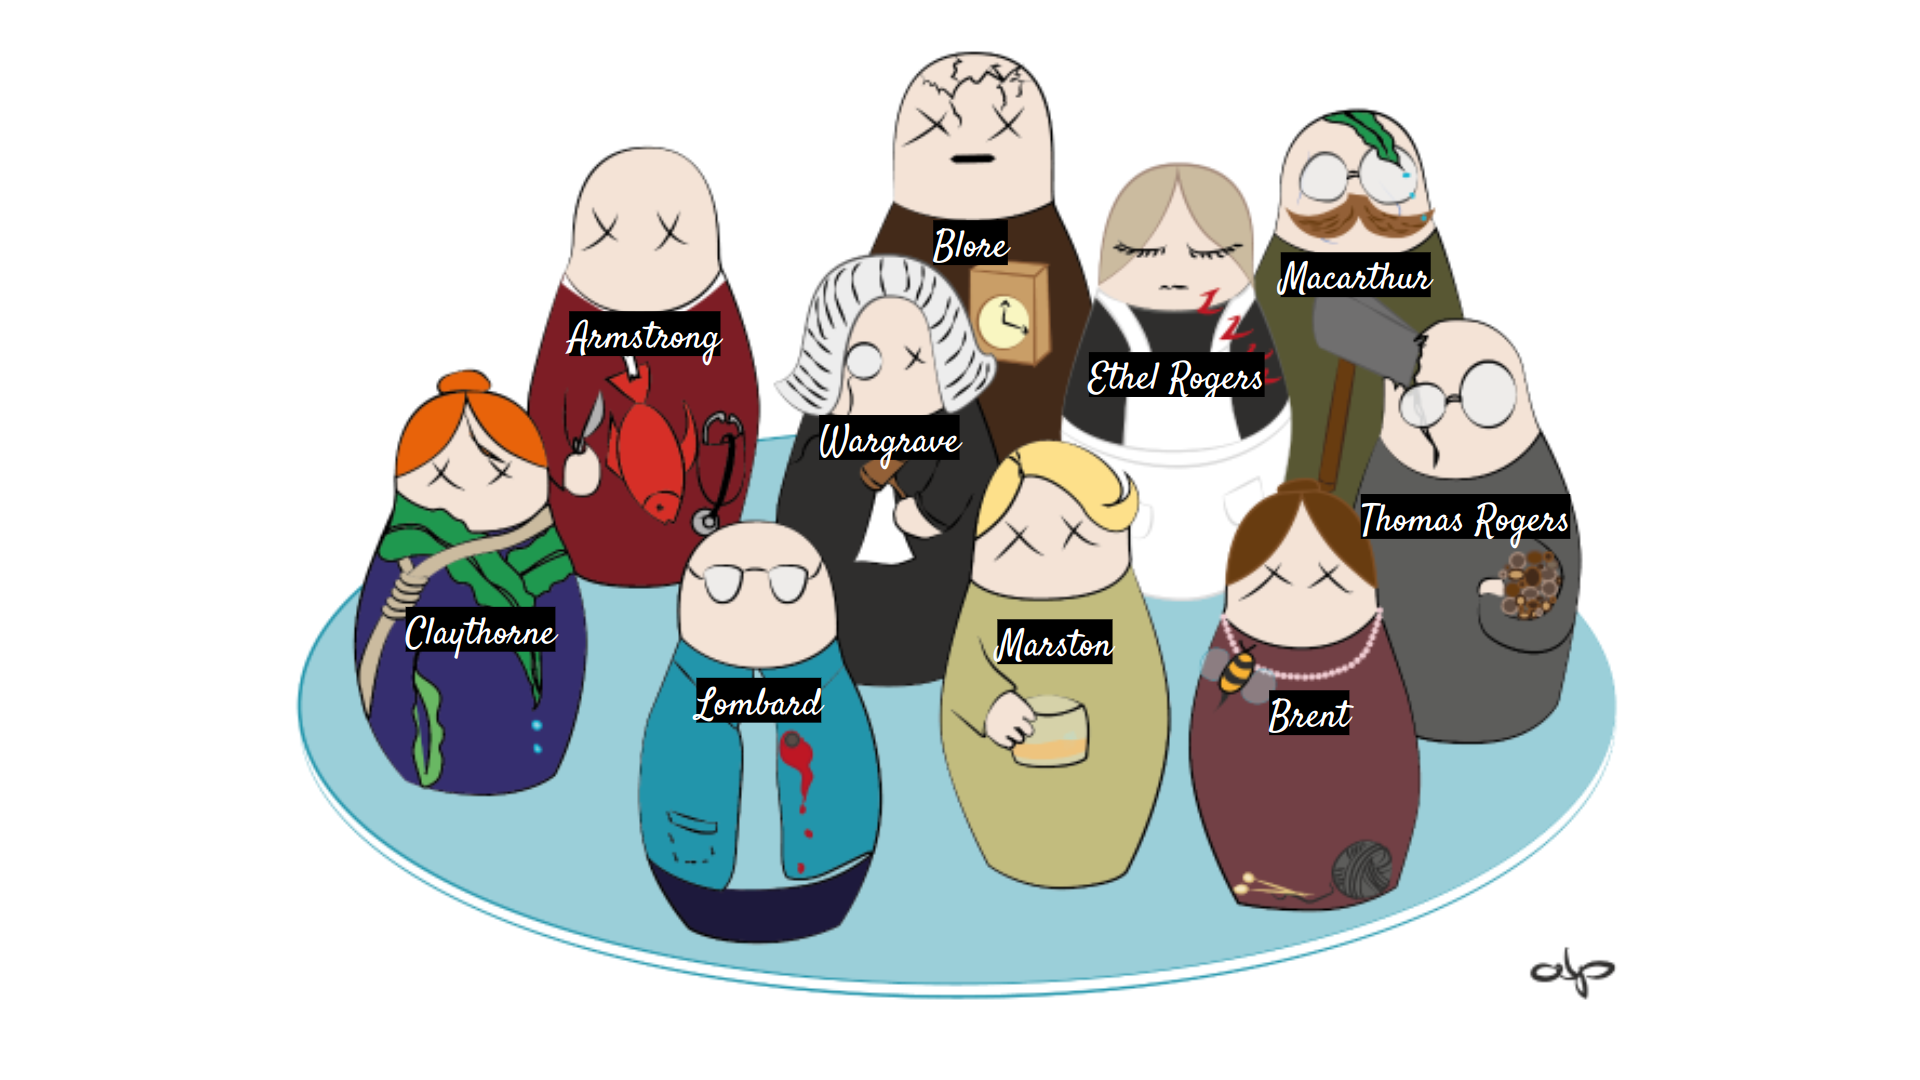

**💡 Indices :**

Les indices dont nous disposons sont les suivants :

1) Le nom du coupable est présent dans au moins 50 phrases ;
2) Hors ponctuation et mots vides, les phrases contenant le nom du coupable totalisent entre 500 et 1500 mots ;
3) Hors ponctuation et mots vides, le verbe le plus fréquent dans les phrases contenant le nom du coupable est un verbe de parole ;
4) Hors ponctuation et mots vides, l'adjectif le plus fréquent dans les phrases contenant le nom du coupable donne un information sur l'apparence du coupable.
5) Le verbe dont le suspect est le plus souvent le sujet ne commence pas par la lettre "i".

**Configuration**

In [ ]:
# Config Colab
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append("/content/drive/MyDrive/Obtic/Ateliers/AT_spaCy") # A adapter selon votre chemin

Mounted at /content/drive


**Chargement du corpus**

In [ ]:
# Chemin vers les données (adapter à vos données)
text_file = "/content/drive/MyDrive/Obtic/Ateliers/AT_spaCy/data/agatha_christie.txt"

import re

# Charger et afficher le corpus
with open(text_file, "r") as f:
    texte = re.sub(r"\n+", " ", f.read())
    texte = re.sub(r"\s+", " ", texte)
    texte = texte.strip()

texte

'Dans le coin fenêtre d’un compartiment fumeurs de première classe, le juge Wargrave, retraité depuis peu, tirait sur son cigare en parcourant avec intérêt les pages politiques du Times. Posant son journal, il regarda par la vitre. Ils traversaient maintenant le Somerset. Il jeta un coup d’œil à sa montre : encore deux heures de voyage. Mentalement, il passa en revue tout ce qui avait paru dans la presse au sujet de l’île du Nègre. Il y avait d’abord eu la nouvelle de son achat par un milliardaire américain fanatique de yachting – assortie de la description de la luxueuse demeure ultra-moderne qu’il faisait construire sur cet îlot au large du Devon. Le fait malencontreux que la toute récente et néanmoins troisième épouse dudit milliardaire n’eût pas le pied marin avait entraîné la mise en vente de l’île et de la maison. Des publicités dithyrambiques avaient alors été placardées un peu partout. Jusqu’au jour où on avait sobrement annoncé qu’elle avait été rachetée par un certain Mr O’Ny

**Traitement du texte avec spaCy**

In [ ]:
# Installer spaCy
!pip install spacy

# Télécharger le modèle français fr_core_news_lg
!python3 -m spacy download fr_core_news_lg

# Importer spaCy
import spacy

# Charger le modèle
nlp = spacy.load('fr_core_news_lg')

# Traiter le texte avec spacy
doc = nlp(texte)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 MB 2.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


💡 **Indice 1 :** Le nom du coupable est présent dans au moins 50 phrases.

In [ ]:
# Objectif : Compter le nombre de phrases dans lesquelles les noms des suspects apparaissent

# Noms des suspects
suspects = ["Armstrong", "Blore", "Brent", "Claythorne", "Lombard", "Macarthur", "Marston", "Wargrave", "Ethel Rogers", "Thomas Rogers"]

# Segmenter en phrases

# Parcourir chaque suspect
    # Initialiser le compteur de phrases dans lesquelles le nom du suspect apparaît
    # Parcourir chaque phrase
        # Si le nom du suspect est dans la phrase
            # Alors on ajoute 1 à son nombre de phrases

    # Affichage

💡 **Indice 2 :** Hors ponctuation et mots vides, les phrases contenant le nom du coupable totalisent entre 500 et 1500 mots.

In [ ]:
# Objectif : Compter le nombre de mots des phrases dans lesquelles les noms des suspects apparaissent

# Parcourir chaque suspect
    # Initialiser le compteur de mots des phrases dans lesquelles le nom du suspect apparaît
    # Parcourir chaque phrase
        # Si le nom du suspect est dans la phrase
            # Traiter la phrase comme un doc
            # Nettoyer la phrase (suppression des stopwords et de la ponctuation)
            # Ajouter la longueur de la phrase au nombre de mots

    # Affichage

💡 **Indice 3 :** Hors ponctuation et mots vides, le verbe le plus fréquent dans les phrases contenant le nom du coupable est un verbe de parole.

In [ ]:
# Objectif : Compter les verbes ("VERB") des phrases dans lesquelles les noms des supects apparaissent et trouver le plus fréquent

# Parcourir chaque suspect
    # Initialiser un dictionnaire des comptes des verbes
    # Parcourir chaque phrase
        # Si le nom du suspect est dans la phrase
            # Traiter la phrase comme un doc
            # Extraire les lemmes des verbes de la phrase (hors stopwords et ponctuation)
            # Parcourir chaque verbe extrait
                # Si le verbe appartient déjà au dictionnaire
                    # Ajouter 1 à sa fréquence
                # Si le verbe n'appartient pas au dictionnaire
                    # Initialiser sa fréquence à 1
    # Extraire le verbe qui a la fréquence la plus élevée

    # Affichage

💡 **Indice 4 :** Hors ponctuation et mots vides, l'adjectif le plus fréquent dans les phrases contenant le nom du coupable donne un information sur l'apparence du coupable.

In [ ]:
# Objectif : Compter les adjectifs ("ADJ") des phrases dans lesquelles les noms des supects apparaissent et trouver le plus fréquent

# Parcourir chaque suspect
    # Initialiser un dictionnaire des comptes des adjectifs
    # Parcourir chaque phrase
        # Si le nom du suspect est dans la phrase
            # Traiter la phrase comme un doc
            # Extraire les lemmes des adjectifs de la phrase (hors stopwords et ponctuation)
            # Parcourir chaque adjectif extrait
                # Si l'adjectif appartient déjà au dictionnaire
                    # Ajouter 1 à sa fréquence
                # Si l'adjectif n'appartient pas au dictionnaire
                    # Initialiser sa fréquence à 1
    # Extraire l'adjectif qui a la fréquence la plus élevée

    # Affichage

💡 **Indice 5 :** Le verbe dont le coupable est le plus souvent le sujet ne commence pas par la lettre "i".

In [ ]:
# Objectif : Trouver les mots auxquels les noms des suspects sont associés par la relation de dépendance "nsubj", les compter et trouver le plus fréquent

# Parcourir chaque suspect
    # Initialiser un dictionnaire des comptes des verbes dont le suspect est le sujet
    # Parcourir chaque phrase
        # Si le nom du suspect est dans la phrase
            # Traiter la phrase comme un doc
            # Extraire le token de la phrase correspondant au nom du suspect
            # Si le nom du sujet a une relation de dépendance "nsubj" avec un verbe ("VERB")
                # Si le lemme de sa tête appartient déjà au dictionnaire
                    # Ajouter 1 à sa fréquence
                # Si le lemme de sa tête n'appartient pas au dictionnaire
                    # Initialiser sa fréquence à 1
    # Extraire le lemme qui a la fréquence la plus élevée

    # Affichage

**Avez-vous démasqué le coupable ?**

<img src="https://st2.depositphotos.com/2101611/6966/v/450/depositphotos_69669865-stock-illustration-mugshot-of-anonymous-male-silhouette.jpg" alt="Stopwords" width="300">